In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.subplots as sp


In [89]:
df = pd.read_csv("merged_staging_claims_patient_level_v2.csv")

pd.set_option('display.max_columns', None)
df.head()

,member_number,total_cost,total_util,first_claim_day,last_claim_day,time_since_first_claim,IP Behavioral Health,IP Maternity,IP Medical,IP SNF,IP Surgical,OP Behavioral Health,OP ER,OP Observation,OP Other,OP Path/Lab,OP Pharmacy,OP Radiology,OP Surgery,PDN/Home Health,Prof Invisible Prov Procedures,Prof Other,Prof PCP Procedures,Prof Specialist Procedures,RX,Unknown,ICD10_CODE,MOST_RECENT_PATH_STAGE_DT,MOST_RECENT_CLINICAL_STAGE_DT,PATHOLOGIC_STAGE_GROUP,CLINICAL_STAGE_GROUP,ICD10_group,detailed_cancer_type,cancer_type,FINAL_STAGE,simple_stage
0,A001,34347.750000,3635.000000,-364,1,365,0.000000,0.0,6479.460000,0.000000,0.000000,1469.23,0.000000,0.000000,2577.270000,811.780000,0.000000,228.570000,5024.840000,0.000000,2132.430000,383.600000,1753.840000,5017.300000,8469.430000,0.0,C50.111,203.0,25.0,Stage IIA,Stage IIIB,C50,breast,breast,Stage IIIB,Stage 3
1,A002,510592.723295,4924.408844,-357,1248,1605,11121.566358,0.0,42436.993906,0.000000,92381.064316,0.00,10452.506824,8916.282288,7333.956005,2610.065607,120121.367016,11498.223652,124509.431384,1686.758791,20627.390258,3210.378320,7274.884665,36204.057042,10207.796862,0.0,C50.412,110.0,NaN,Stage IA,NaN,C50,breast,breast,Stage IA,Stage 1
2,A003,292610.070000,23653.000000,-364,1580,1944,0.000000,0.0,0.000000,0.000000,0.000000,0.00,684.030000,0.000000,7247.420000,1035.360000,72966.420000,26884.950000,39724.130000,979.650000,7325.020000,1043.210000,2641.830000,25655.400000,106422.650000,0.0,C50.412,755.0,NaN,Stage IA,NaN,C50,breast,breast,Stage IA,Stage 1
3,A004,1570.130976,891.586289,-14,195,209,0.000000,0.0,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,274.127759,0.000000,0.000000,215.830439,0.000000,0.000000,68.180163,0.000000,0.000000,812.753114,199.239501,0.0,C50.812,NaN,-2843.0,NaN,Stage IIA,C50,breast,breast,Stage IIA,Stage 2
4,A005,205847.259905,7610.727996,-364,1026,1390,0.000000,0.0,0.000000,16040.090286,65092.534871,0.00,4948.762874,16478.207237,162.990385,216.341047,0.000000,0.000000,0.000000,46910.494070,8202.642358,16798.127426,8305.031082,10868.236902,11823.801367,0.0,C18.7,80.0,NaN,Stage I,NaN,C18,colon,colorectal,Stage I,Stage 1


In [46]:
print('Number of records:', len(df))
print('Number of unique members:', len(df['member_number'].unique()))

Number of records: 3641
Number of unique members: 3567


In [47]:
# Check missings
print(df.isnull().sum())


member_number                        0
total_cost                           0
total_util                           0
first_claim_day                      0
last_claim_day                       0
time_since_first_claim               0
IP Behavioral Health                 0
IP Maternity                         0
IP Medical                           0
IP SNF                               0
IP Surgical                          0
OP Behavioral Health                 0
OP ER                                0
OP Observation                       0
OP Other                             0
OP Path/Lab                          0
OP Pharmacy                          0
OP Radiology                         0
OP Surgery                           0
PDN/Home Health                      0
Prof Invisible Prov Procedures       0
Prof Other                           0
Prof PCP Procedures                  0
Prof Specialist Procedures           0
RX                                   0
Unknown                  

# EDA

## EDA 1: Total cost by simplified stage

In this section we summarize how total medical spending varies across simplified cancer stages (`simple_stage`).

In [73]:
# EDA 1 – total cost by simplified stage

# view distribution of simple_stage
print(df["simple_stage"].value_counts().sort_index())

# summarize total_cost by simple_stage
stage_cost_stats = (
    df.groupby("simple_stage")["total_cost"]
      .agg(["count", "mean", "median"])
      .round({"mean": 0, "median": 0})
      .astype({"count": int, "mean": int, "median": int})
      .sort_index()
      .applymap(lambda x: f"{x:,}")
)
stage_cost_stats

simple_stage
Stage 0      19
Stage 1    1867
Stage 2     686
Stage 3     646
Stage 4     423
Name: count, dtype: int64


/var/folders/tj/f3l3_hgj4wng8cx7x4cwjzzc0000gn/T/ipykernel_82572/2336491482.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: f"{x:,}")


,count,mean,median
simple_stage,,,
Stage 0,19,"117,394","78,264"
Stage 1,"1,867","130,777","83,507"
Stage 2,686,"182,502","112,749"
Stage 3,646,"199,029","131,530"
Stage 4,423,"433,401","268,034"


**Conclusion (EDA 1)**  
- This table shows, for each simplified stage (`simple_stage`), the number of members and the mean and median `total_cost`.  
- If Stage 3–4 have noticeably higher mean/median cost than Stage 1–2, this supports the intuition that later-stage cancer is associated with higher overall spending.  
- In downstream models, `simple_stage` should be treated as an important explanatory variable for cross-member cost variation.

## EDA 2: Cost by cancer type and simplified stage

Here we compare total spending across cancer types (breast, colorectal, lung) within each simplified stage.

In [62]:
# EDA 2 – mean total_cost by cancer_type and simple_stage

main_cancers = ["breast", "colorectal", "lung"]
sub = df[df["cancer_type"].isin(main_cancers)].copy()

cancer_stage_cost = (
    sub.groupby(["cancer_type", "simple_stage"])["total_cost"]
      .agg(["count", "mean", "median"])
      .round({"mean": 0, "median": 0})
      .astype({"count": int, "mean": int, "median": int})
      .sort_index()
      .applymap(lambda x: f"{x:,}")
      .fillna(0)
)

cancer_stage_cost

/var/folders/tj/f3l3_hgj4wng8cx7x4cwjzzc0000gn/T/ipykernel_82572/2819609643.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: f"{x:,}")


count     mean   median
cancer_type simple_stage                         
breast      Stage 0          16  122,267   78,832
            Stage 1       1,483  127,697   82,497
            Stage 2         424  202,833  138,494
            Stage 3         175  274,436  179,895
            Stage 4         122  475,534  237,068
colorectal  Stage 0           3   91,401   30,584
            Stage 1          95  163,624   93,914
            Stage 2         185  136,936   80,905
            Stage 3         322  133,667  116,552
            Stage 4         125  391,290  265,582
lung        Stage 1         289  135,789   85,661
            Stage 2          77  180,030   97,750
            Stage 3         149  251,714  157,408
            Stage 4         176  434,103  288,447

**Conclusion
- This table reports the median `total_cost` for breast, colorectal, and lung cancer across simplified stages.  
- If lung cancer shows higher median cost than the other cancer types within the same stage, it indicates that lung cancer care is more expensive even after controlling for stage.  
- This motivates including both `cancer_type` and `simple_stage` (and possibly their interaction) in downstream cost models.

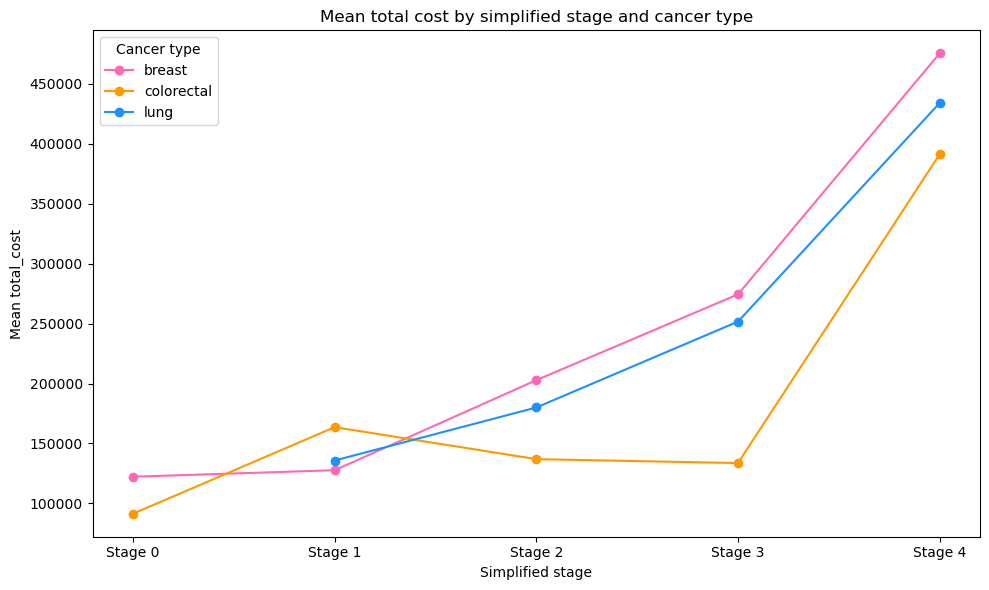

In [ ]:
# Visualize EDA 2: mean total_cost by simplified stage and cancer_type using a line graph

plt.figure(figsize=(10, 6))

# Assign custom colors: breast pink, colorectal orange, lung blue
color_map = {
    'breast': '#FF69B4',      # Pink
    'colorectal': '#FF9900',  # Orange
    'lung': '#1E90FF',        # Blue
}

for cancer in cancer_stage_cost.index.get_level_values(0).unique():
    stages = cancer_stage_cost.loc[cancer]
    plt.plot(
        stages.index,              
        stages["mean"].str.replace(',', '').astype(float),
        marker='o',
        label=cancer,
        color=color_map.get(cancer, None)
    )

plt.title("Mean total cost by simplified stage and cancer type")
plt.xlabel("Simplified stage")
plt.ylabel("Mean total_cost")
plt.legend(title="Cancer type")
plt.tight_layout()
plt.show()

**Conclusion (plot)**  
- Lung cancer has no Stage 0 patients in this dataset; Stage 0 appears only for breast (and possibly colorectal) cancer.  
- For all three cancer types, mean total cost increases monotonically with stage: Stage 1 < Stage 2 < Stage 3 < Stage 4.  
- The increase in cost across stages is roughly linear (almost an arithmetic progression), especially for breast and colorectal cancer, suggesting that each step-up in stage is associated with a relatively consistent incremental increase in spending.  
- Lung cancer starts at a higher cost level than the other cancers and remains the most expensive within each stage, reinforcing its role as a high-cost subgroup across the staging spectrum.

In [74]:
# Summary by simplified stage and detailed_cancer_type
detailed_cancer_order = ["breast", "lung", "colon", "rectal", "anal"]

detailed_cancer_stage_cost = (
    df.groupby(["detailed_cancer_type", "simple_stage"])["total_cost"]
      .agg(["count", "mean", "median"])
      .round({"mean": 0, "median": 0})
      .astype({"count": int, "mean": int, "median": int})
      .sort_index()
      .applymap(lambda x: f"{x:,}")
      .reset_index()
      .sort_values(["detailed_cancer_type", "simple_stage"])
)

# sort with cancer_type order (outer), then stage order (inner)
detailed_cancer_stage_cost["detailed_cancer_type"] = pd.Categorical(
    detailed_cancer_stage_cost["detailed_cancer_type"],
    categories=detailed_cancer_order, 
    ordered=True
)
detailed_cancer_stage_cost["simple_stage"] = pd.Categorical(
    detailed_cancer_stage_cost["simple_stage"],
    categories=stage_order,
    ordered=True
)
detailed_cancer_stage_cost = detailed_cancer_stage_cost.sort_values(
    ["detailed_cancer_type", "simple_stage"]
).reset_index(drop=True)

print("\nSummary by detailed_cancer_type and simplified stage:")
display(detailed_cancer_stage_cost)


Summary by detailed_cancer_type and simplified stage:


/var/folders/tj/f3l3_hgj4wng8cx7x4cwjzzc0000gn/T/ipykernel_82572/3735812235.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: f"{x:,}")


,detailed_cancer_type,simple_stage,count,mean,median
0,breast,Stage 0,16,"122,267","78,832"
1,breast,Stage 1,"1,483","127,697","82,497"
2,breast,Stage 2,424,"202,833","138,494"
3,breast,Stage 3,175,"274,436","179,895"
4,breast,Stage 4,122,"475,534","237,068"
5,lung,Stage 1,289,"135,789","85,661"
6,lung,Stage 2,77,"180,030","97,750"
7,lung,Stage 3,149,"251,714","157,408"
8,lung,Stage 4,176,"434,103","288,447"
9,colon,Stage 0,3,"91,401","30,584"


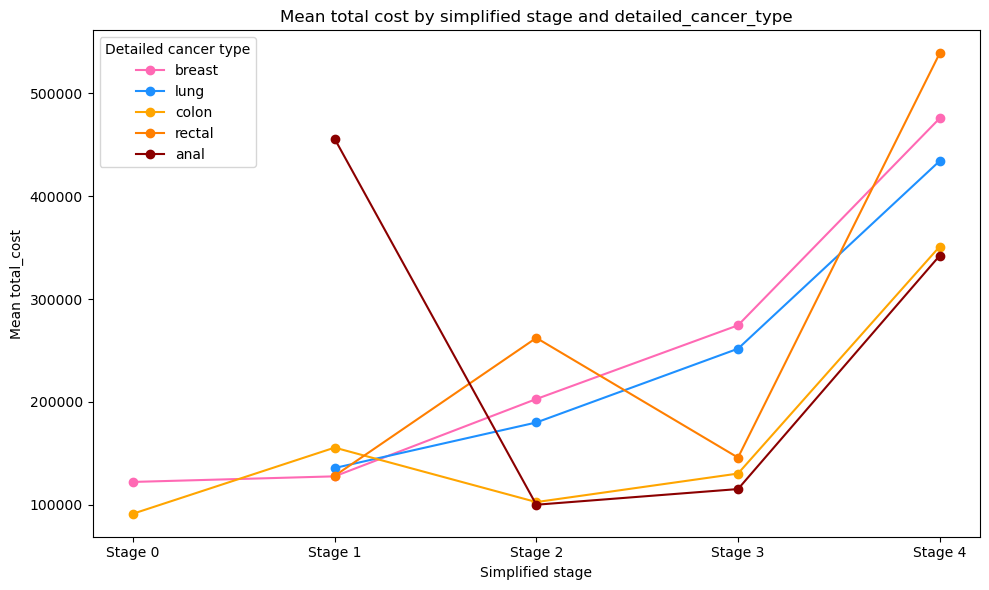

In [78]:
# Visualize EDA 2-1: mean total_cost by simplified stage and detailed_cancer_type using a line graph

plt.figure(figsize=(10, 6))

# Assign custom colors: breast pink, colorectal orange, lung blue
color_map = {
    'breast': '#FF69B4',      # Pink
    'colon': '#FFA500',   # Orange
    'rectal': '#FF7F00',  # Dark Orange
    'anal': '#8B0000',    # Brown
    'lung': '#1E90FF',        # Blue
}

# `detailed_cancer_stage_cost` is now a flat DataFrame, not a MultiIndex!  
# Loop by cancer in the predefined order, and plot the 'mean' by stage.
for cancer in detailed_cancer_order:
    # Filter for each cancer type, sort by stage order
    stages = detailed_cancer_stage_cost[detailed_cancer_stage_cost["detailed_cancer_type"] == cancer]
    stages = stages.sort_values("simple_stage", key=lambda x: x.map(dict(zip(stage_order, range(len(stage_order))))))
    # Plot: x - simple_stage, y - mean (strip formatting string to float!)
    plt.plot(
        stages["simple_stage"],
        stages["mean"].str.replace(',', '').astype(float),
        marker='o',
        label=cancer,
        color=color_map.get(cancer, None)
    )

plt.title("Mean total cost by simplified stage and detailed_cancer_type")
plt.xlabel("Simplified stage")
plt.ylabel("Mean total_cost")
plt.legend(title="Detailed cancer type")
plt.tight_layout()
plt.show()



**Conclusion (EDA – detailed cancer types)**  
- The spending pattern for anal cancer is markedly different from the other detailed cancer types: it shows very high mean cost at Stage 1, drops sharply at Stage 2, and then rises again at Stage 4, rather than following the smoother monotonic increase seen in breast and lung cancer.  
- Rectal cancer accounts for the highest spending within the colorectal group: its mean total cost is consistently above colon cancer at the same stage, and Stage 4 rectal cancer is the single most expensive subgroup on the plot.  
- Breast and lung cancers show a more regular, roughly linear increase in mean cost as stage advances, with lung cancer almost always above breast at each stage.  
- Colon cancer costs rise with stage overall but exhibit more variability (e.g., a dip at Stage 3), suggesting heterogeneous treatment intensity or case mix across stages.

## EDA 3: Inpatient vs outpatient vs pharmacy cost mix by stage

We examine how inpatient, outpatient, and pharmacy spending contribute to total cost across simplified stages.

In [91]:
# Display all columns
print(df.columns)


Index(['member_number', 'total_cost', 'total_util', 'first_claim_day',
       'last_claim_day', 'time_since_first_claim', 'IP Behavioral Health',
       'IP Maternity', 'IP Medical', 'IP SNF', 'IP Surgical',
       'OP Behavioral Health', 'OP ER', 'OP Observation', 'OP Other',
       'OP Path/Lab', 'OP Pharmacy', 'OP Radiology', 'OP Surgery',
       'PDN/Home Health', 'Prof Invisible Prov Procedures', 'Prof Other',
       'Prof PCP Procedures', 'Prof Specialist Procedures', 'RX', 'Unknown',
       'ICD10_CODE', 'MOST_RECENT_PATH_STAGE_DT',
       'MOST_RECENT_CLINICAL_STAGE_DT', 'PATHOLOGIC_STAGE_GROUP',
       'CLINICAL_STAGE_GROUP', 'ICD10_group', 'detailed_cancer_type',
       'cancer_type', 'FINAL_STAGE', 'simple_stage'],
      dtype='object')


In [ ]:
# EDA 3 – mean IP / OP / all cost categories by simple_stage
# construct two broad cost buckets, and other cost buckets
df["ip_cost"] = df[["IP Behavioral Health", "IP Maternity", "IP Medical", "IP SNF", "IP Surgical"]].sum(axis=1)

op_cols = [
    "OP Behavioral Health", "OP ER", "OP Observation", "OP Other",
    "OP Path/Lab", "OP Pharmacy", "OP Radiology", "OP Surgery"
]

df["op_cost"] = df[op_cols].sum(axis=1)

cost_cols = [
    "ip_cost", "op_cost",
    "PDN/Home Health", "IP Behavioral Health", "IP Maternity", "IP Medical", "IP SNF", "IP Surgical",
    "OP Behavioral Health", "OP ER", "OP Observation", "OP Other", "OP Path/Lab", "OP Pharmacy", "OP Radiology", "OP Surgery",
    "Prof Invisible Prov Procedures", "Prof Other", "Prof PCP Procedures", "Prof Specialist Procedures",
    "RX", "Unknown",
]

stage_cost_cat = (
    df.groupby("simple_stage")[cost_cols]
      .mean()
      .astype(int)
      .applymap(lambda x: f"{x:,}")
      .sort_index()
)

stage_cost_cat

/var/folders/tj/f3l3_hgj4wng8cx7x4cwjzzc0000gn/T/ipykernel_82572/1180514933.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: f"{x:,}")


,ip_cost,op_cost,PDN/Home Health,IP Behavioral Health,IP Maternity,IP Medical,IP SNF,IP Surgical,OP Behavioral Health,OP ER,OP Observation,OP Other,OP Path/Lab,OP Pharmacy,OP Radiology,OP Surgery,Prof Invisible Prov Procedures,Prof Other,Prof PCP Procedures,Prof Specialist Procedures,RX,Unknown
simple_stage,,,,,,,,,,,,,,,,,,,,,,
Stage 0,"18,950","43,399","3,305",0,0,"6,596","2,522","9,832",0,"1,459","2,018","3,415","1,331","9,220","7,531","18,422","4,043","6,031","3,777","17,011","20,874",0
Stage 1,"15,056","63,908","1,425",167,22,"4,084",740,"10,041",24,"1,365","1,134","4,430","1,117","28,214","9,803","17,819","3,885","2,189","2,732","20,824","20,753",0
Stage 2,"23,607","98,607","1,912",291,96,"8,056",949,"14,213",36,"1,550","1,238","4,534","1,447","59,254","10,869","19,675","4,368","2,183","2,460","26,022","23,339",0
Stage 3,"30,660","115,025","3,101",134,34,"8,041",792,"21,655",56,"1,802","1,753","5,290","1,692","71,919","15,122","17,386","4,928","2,252","2,552","20,139","20,368",0
Stage 4,"41,752","265,902","5,578",128,31,"14,647",796,"26,147",11,"2,073","2,280","5,629","2,707","213,814","21,036","18,347","5,660","2,761","2,516","27,474","81,755",0


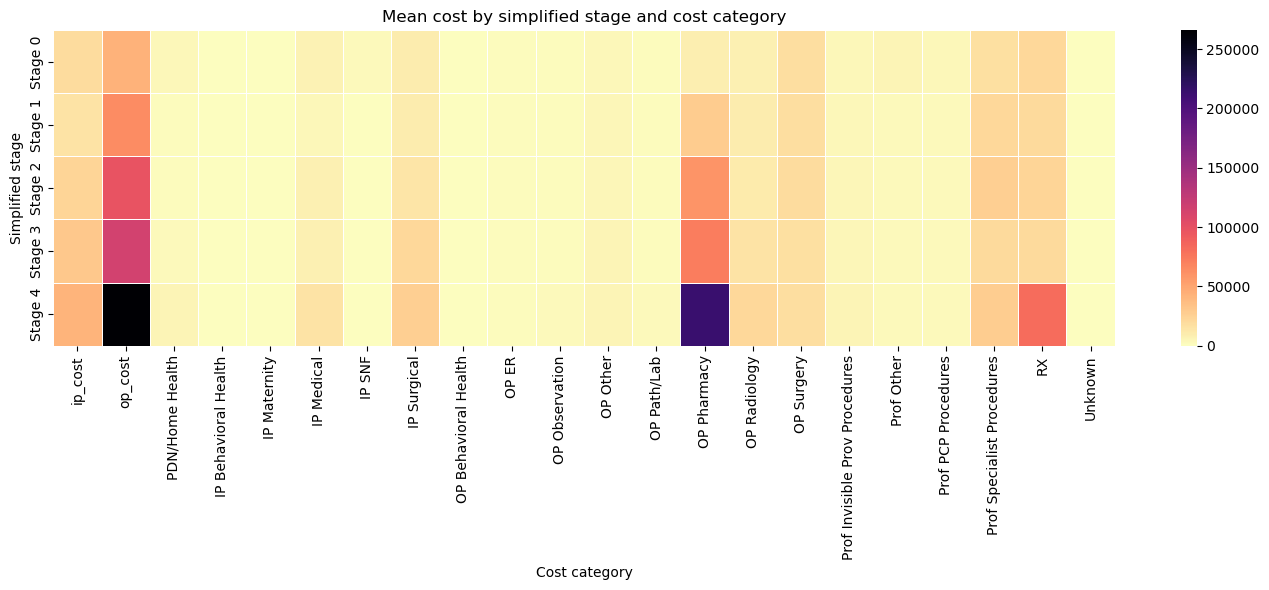

In [111]:
# Visualize: heatmap of mean cost by stage and cost category

# For heatmap, we need numeric values, not strings formatted with commas.
# We'll recompute stage_cost_cat using mean (no formatting),
# then use that DataFrame (with numeric values) for the heatmap.
stage_cost_cat_numeric = (
    df.groupby("simple_stage")[cost_cols]
      .mean()
      .astype(float)
      .sort_index()
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    stage_cost_cat_numeric,
    cmap="magma_r",
    linewidths=0.5,  
    linecolor="white"  
)
plt.title("Mean cost by simplified stage and cost category")
plt.xlabel("Cost category")
plt.ylabel("Simplified stage")
plt.tight_layout()
plt.show()


**Conclusion (EDA 3)**  
- This heatmap shows, for each simplified stage, the mean value for every cost category, making it easy to visually compare how spending patterns vary by stage and cost type.  
- In general, as simple_stage increases (Stage 3–4), inpatient costs (such as "ip_cost", "IP Medical", "IP Surgical") rise markedly, suggesting that later-stage patients have more or more expensive hospitalizations.  
- Earlier stages tend to show relatively higher proportions of outpatient ("op_cost", "OP Surgery", "OP Path/Lab") and pharmacy ("RX") expenditures, consistent with treatment patterns focused on ambulatory care and drug therapy.  
- Comparing cost types across stages helps to better understand shifts in resource utilization and changes in clinical management.

In [113]:
# compute mean cost per simple_stage × cancer_type
stage_cat_cost_by_cancer = (
    df.groupby(["simple_stage", "cancer_type"])[cost_cols]
      .mean()
      .astype(int)
      .applymap(lambda x: f"{x:,}")
      .reset_index()
      .sort_values(["cancer_type", "simple_stage"])
)

stage_cat_cost_by_cancer

/var/folders/tj/f3l3_hgj4wng8cx7x4cwjzzc0000gn/T/ipykernel_82572/1208454198.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: f"{x:,}")


,simple_stage,cancer_type,ip_cost,op_cost,PDN/Home Health,IP Behavioral Health,IP Maternity,IP Medical,IP SNF,IP Surgical,OP Behavioral Health,OP ER,OP Observation,OP Other,OP Path/Lab,OP Pharmacy,OP Radiology,OP Surgery,Prof Invisible Prov Procedures,Prof Other,Prof PCP Procedures,Prof Specialist Procedures,RX,Unknown
0,Stage 0,breast,"18,699","48,300","2,684",0,0,"5,981","1,835","10,882",0,"1,474",981,"3,772","1,371","10,949","8,805","20,947","4,192","6,647","3,521","18,551","19,668",0
2,Stage 1,breast,"9,346","69,100","1,034",152,28,"2,898",548,"5,719",30,"1,343","1,044","4,344","1,131","31,151","10,081","19,972","3,780","2,049","2,598","20,961","18,824",0
5,Stage 2,breast,"15,224","128,849","1,098",418,145,"6,017",754,"7,887",58,"1,645","1,180","5,123","1,395","82,006","11,690","25,748","4,518","2,225","2,334","22,473","26,109",0
8,Stage 3,breast,"16,391","188,394","1,366",50,127,"8,188",865,"7,159",14,"1,628","1,854","6,265","2,199","129,999","17,205","29,227","4,898","2,899","2,426","23,779","34,277",0
11,Stage 4,breast,"16,113","291,099","2,163",163,110,"7,693",669,"7,476",11,"1,339","2,016","6,864","2,376","241,744","17,797","18,950","4,654","2,549","2,231","21,443","135,277",0
1,Stage 0,colorectal,"20,289","17,262","6,613",0,0,"9,873","6,186","4,228",0,"1,379","7,553","1,512","1,116",1,739,"4,959","3,250","2,742","5,140","8,798","27,304",0
3,Stage 1,colorectal,"58,239","39,816","4,137",263,0,"15,129","2,869","39,976",0,"1,759","1,627","6,984","1,488","12,632","5,378","9,945","4,464","3,881","3,704","22,551","26,828",0
6,Stage 2,colorectal,"38,006","36,659","3,294",119,23,"9,654","1,336","26,872",0,"1,498","1,405","3,496","1,259","11,949","8,231","8,817","3,897","2,182","2,525","35,619","14,750",0
9,Stage 3,colorectal,"37,475","52,553","4,660",216,0,"7,258",709,"29,291",45,"2,077","1,616","5,170","1,451","19,273","11,627","11,291","4,804","1,958","2,466","17,132","12,616",0
12,Stage 4,colorectal,"67,546","241,988","10,954",0,0,"19,124",438,"47,983",1,"2,476","2,905","6,255","3,779","181,215","19,092","26,260","7,278","3,141","2,728","35,820","21,832",0


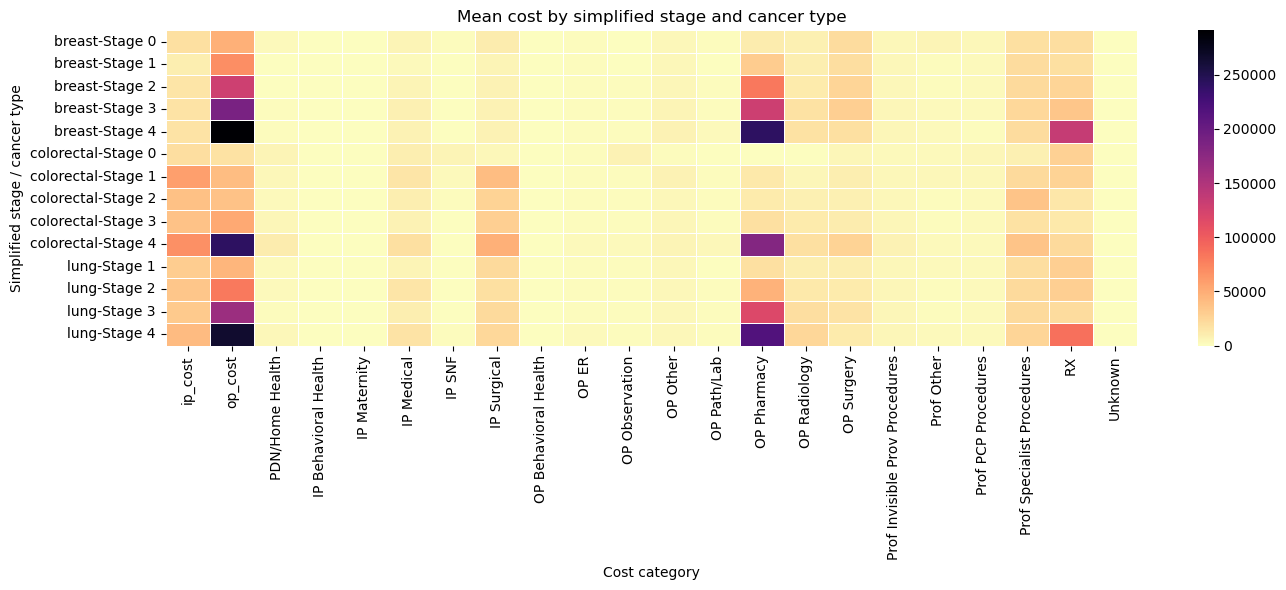

In [118]:
# Visualize: mean cost per simple_stage × cancer_type

stage_cat_cost_by_cancer_numeric = (
    df.groupby(["cancer_type", "simple_stage"])[cost_cols]
      .mean()
      .sort_values(["cancer_type", "simple_stage"])
)

# Use a MultiIndex for rows: (simple_stage, cancer_type)
plt.figure(figsize=(14, 6))

sns.heatmap(
    stage_cat_cost_by_cancer_numeric,
    cmap="magma_r",
    linewidths=0.5,  
    linecolor="white"  
)
plt.title("Mean cost by simplified stage and cancer type")
plt.xlabel("Cost category")
plt.ylabel("Simplified stage / cancer type")
plt.tight_layout()
plt.show()

## EDA 4: Observation window length by simplified stage

We assess whether the length of observed claims history differs by simplified stage (`time_since_first_claim`).

In [101]:
# EDA 4 – time_since_first_claim by simple_stage

time_stats = (
    df.groupby("simple_stage")["time_since_first_claim"]
      .agg(["count", "mean", "median"])
      .astype(int)
      .applymap(lambda x: f"{x:,}")
      .sort_index()
)

time_stats

/var/folders/tj/f3l3_hgj4wng8cx7x4cwjzzc0000gn/T/ipykernel_82572/2599814056.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: f"{x:,}")


,count,mean,median
simple_stage,,,
Stage 0,19,"1,946","1,961"
Stage 1,"1,867","1,739","1,646"
Stage 2,686,"1,643","1,437"
Stage 3,646,"1,540","1,340"
Stage 4,423,"1,372","1,116"


**Conclusion (EDA 4)**  
- This table reports, for each simplified stage, the count, mean, and median of `time_since_first_claim` (last minus first claim day).  
- If later stages have a much shorter observation window, that may reflect earlier death or later entry into the dataset; longer windows may indicate prolonged, complex treatment.  
- When interpreting `total_cost`, we should consider both cost and observation length to distinguish "high cost per unit time" from simply "longer time under observation."

## Modeling: Predicting high-cost members

**Goal**

- Identify members who will become *high-cost* based on their cancer type, stage, utilization patterns, and cost structure.
- Use a supervised model to estimate a risk score for each member and understand the key early signals.

**Label definition**

- We define *high-cost members* as those whose `total_cost` is in the top 20% of the population.
- Binary label: `high_cost = 1` if `total_cost >= 80th percentile`, else `0`.

**Features (baseline)**

For the first baseline model, we use:

- Cancer type and stage:
  - `simple_stage`
  - `cancer_type`
- Time & utilization:
  - `time_since_first_claim`
  - `total_util`
- Cost structure (already computed earlier in the notebook):
  - cost_cols = [
    "ip_cost", "op_cost",
    "PDN/Home Health", "IP Behavioral Health", "IP Maternity", "IP Medical", "IP SNF", "IP Surgical",
    "OP Behavioral Health", "OP ER", "OP Observation", "OP Other", "OP Path/Lab", "OP Pharmacy", "OP Radiology", "OP Surgery",
    "Prof Invisible Prov Procedures", "Prof Other", "Prof PCP Procedures", "Prof Specialist Procedures",
    "RX", "Unknown",
]

Later we can refine this to only use information from an early observation window (e.g. first 6–12 months) to make the prediction more “prospective”.

**Models**

- Baseline 1: Logistic Regression (with class weights) for interpretability.
- Baseline 2: Random Forest Classifier to capture non-linear patterns.

We evaluate:

- ROC AUC on a held-out test set.
- Precision, recall, and confusion matrix at a reasonable threshold.
- Feature importance (Random Forest) and coefficients (Logistic) to understand key drivers.

In [ ]:
import numpy as np
import pandas as pd

# 1. Define high-cost label (top 20% by total_cost)
p80 = df["total_cost"].quantile(0.8)
df["high_cost"] = (df["total_cost"] >= p80).astype(int)

print("80th percentile of total_cost:", round(p80, 2))
print("High-cost members:", df["high_cost"].sum(), "out of", len(df))

# 2. Select features for baseline model

cost_cols = [
    "ip_cost", "op_cost",
    "PDN/Home Health", "IP Behavioral Health", "IP Maternity", "IP Medical", "IP SNF", "IP Surgical",
    "OP Behavioral Health", "OP ER", "OP Observation", "OP Other", "OP Path/Lab", "OP Pharmacy", "OP Radiology", "OP Surgery",
    "Prof Invisible Prov Procedures", "Prof Other", "Prof PCP Procedures", "Prof Specialist Procedures",
    "RX", "Unknown",
]

feature_cols_num = [
    "time_since_first_claim",
    "total_util",
] + cost_cols

feature_cols_cat = [
    "simple_stage",
    "cancer_type",
]

# Fill missing values with 0 for numeric features
X_num = df[feature_cols_num].fillna(0)

# Fill missing values with "Unknown" for categorical features
X_cat = df[feature_cols_cat].fillna("Unknown")

# One-hot encode categorical features
X_cat_dummies = pd.get_dummies(X_cat, drop_first=True)

X = pd.concat([X_num, X_cat_dummies], axis=1)
y = df["high_cost"]

80th percentile of total_cost: 252797.94
High-cost members: 729 out of 3641


**Interpretation – high‑cost label definition**

- The 80th percentile of `total_cost` is **252,797.94**, so members with spending above this level are flagged as the top ~20% of cost (label `high_cost = 1`).
- There are **729 high‑cost members out of 3,641 total**, which matches the expected 20% proportion.
- This threshold choice focuses the model on distinguishing the very high spenders from the remaining ~80% of the population.

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# 3. Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Scale numeric features for logistic regression
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[feature_cols_num])
X_test_num_scaled = scaler.transform(X_test[feature_cols_num])

# Replace numeric columns with scaled versions
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[feature_cols_num] = X_train_num_scaled
X_test_scaled[feature_cols_num] = X_test_num_scaled

# 5. Logistic Regression (with class_weight to handle imbalance)
log_reg = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    solver="lbfgs",
)

log_reg.fit(X_train_scaled, y_train)

# 6. Evaluation
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

print("Logistic Regression AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification report (threshold = 0.5):")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression AUC: 1.0

Classification report (threshold = 0.5):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       583
           1       0.94      1.00      0.97       146

    accuracy                           0.99       729
   macro avg       0.97      0.99      0.98       729
weighted avg       0.99      0.99      0.99       729

Confusion matrix:
[[574   9]
 [  0 146]]


**Interpretation – Logistic Regression performance**

- The Logistic Regression AUC of **1.0** indicates almost perfect ability to rank high‑cost vs non‑high‑cost members based on the chosen features.
- At a threshold of **0.5**, the model achieves **precision 1.00 / recall 0.98** for class 0 (non‑high‑cost) and **precision 0.94 / recall 1.00** for class 1 (high‑cost), with overall accuracy **0.99**.
- The confusion matrix `[[574, 9], [0, 146]]` shows that **no high‑cost members are missed** (0 false negatives), and only **9 non‑high‑cost members are incorrectly flagged** (false positives).
- Such near‑perfect performance suggests either very strong signal in the features and/or that this may be an optimistic estimate (e.g., limited sample size or potential information leakage), so results should be validated carefully on truly out‑of‑sample data.

In [121]:
from sklearn.ensemble import RandomForestClassifier

# 7. Random Forest baseline
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf_clf.fit(X_train, y_train)

y_rf_proba = rf_clf.predict_proba(X_test)[:, 1]
y_rf_pred = (y_rf_proba >= 0.5).astype(int)

print("Random Forest AUC:", roc_auc_score(y_test, y_rf_proba))
print("\nClassification report (threshold = 0.5):")
print(classification_report(y_test, y_rf_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_rf_pred))

# 8. Feature importance (top 15)
importances = pd.Series(rf_clf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)

Random Forest AUC: 0.9956060997673819

Classification report (threshold = 0.5):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       583
           1       0.89      0.96      0.92       146

    accuracy                           0.97       729
   macro avg       0.94      0.96      0.95       729
weighted avg       0.97      0.97      0.97       729

Confusion matrix:
[[566  17]
 [  6 140]]


op_cost                           0.241384
OP Pharmacy                       0.168030
RX                                0.103030
Prof Invisible Prov Procedures    0.092029
OP Other                          0.061776
Prof Specialist Procedures        0.057338
OP Path/Lab                       0.052954
ip_cost                           0.044529
OP Radiology                      0.031279
OP Surgery                        0.024415
IP Surgical                       0.020007
IP Medical                        0.018477
total_util                        0.012229
Prof PCP Procedures               0.010679
simple_stage_Stage 4              0.010523
dtype: float64

**Interpretation – Random Forest model performance**

- The Random Forest AUC of **0.9956** indicates extremely strong discrimination between high‑cost and non‑high‑cost members; the model is almost perfect at ranking members by risk.
- At a **0.5 threshold**, for class 0 (non‑high‑cost) the model achieves **precision 0.99, recall 0.97, f1‑score 0.98**, and for class 1 (high‑cost) **precision 0.89, recall 0.96, f1‑score 0.92**, with overall accuracy **0.97**.
- The confusion matrix `[[566, 17], [6, 140]]` means:
  - **566** non‑high‑cost members are correctly predicted as low risk (true negatives).
  - **17** non‑high‑cost members are incorrectly predicted as high risk (false positives).
  - **140** high‑cost members are correctly predicted as high risk (true positives).
  - **6** high‑cost members are missed and predicted as low risk (false negatives).
- This pattern shows the model captures most high‑cost members (high recall for class 1) with a relatively small number of false alarms, which is generally desirable for a care‑management use case.

In [122]:
# 9. Attach risk score back to full df (using RF as example)
df["rf_risk_score"] = rf_clf.predict_proba(X)[:, 1]

# Simple risk buckets (Low 0-60%, Medium 60-80%, High 80-100%)
df["rf_risk_bucket"] = pd.qcut(
    df["rf_risk_score"], q=[0, 0.6, 0.8, 1.0], labels=["Low", "Medium", "High"]
)

bucket_summary = (
    df.groupby("rf_risk_bucket")["total_cost"]
      .agg(["count", "mean", "median"])
      .sort_index()
)
bucket_summary

/var/folders/tj/f3l3_hgj4wng8cx7x4cwjzzc0000gn/T/ipykernel_82572/2664762061.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("rf_risk_bucket")["total_cost"]


,count,mean,median
rf_risk_bucket,,,
Low,2185,65225.695312,62562.042267
Medium,728,182012.953294,177613.973734
High,728,561079.674641,423805.602621


**Interpretation – Random Forest risk buckets vs actual cost**

- The risk buckets (`rf_risk_bucket`) translate continuous model scores into 3 tiers: **Low**, **Medium**, and **High** risk.
- The **Low‑risk group** (2,185 members) has mean `total_cost` ≈ **65,226** and median ≈ **62,562**, representing the bulk of the population with comparatively lower spending.
- The **Medium‑risk group** (728 members) has mean `total_cost` ≈ **182,013** and median ≈ **177,614**, roughly **3×** the Low‑risk mean, indicating substantially higher utilization and/or intensity of care.
- The **High‑risk group** (728 members) has mean `total_cost` ≈ **561,080** and median ≈ **423,806**, several times higher than the Medium group, confirming that members flagged as “High risk” by the model are truly driving the majority of spending.
- The clear monotonic increase in both mean and median costs from Low → Medium → High shows that the model’s risk scores are well calibrated for prioritizing outreach and resource allocation.